# CIFAR-100 Object Recognition using HOG-SVM and Convolutional Neural Networks

---

subject: Applied Machine Learning- CIS 6213 | Instructor: Dr. Ali Alqahtani|


Student: Reema Mohammed | ID: 447813323 

---


# Introduction

Object recognition is an important task in machine learning and computer vision. In this project our objective is to compare the effectiveness of traditional machine learning techniques with deep learning methods for classify the testing images into object categories. 

In this project, the CIFAR-100 dataset was used. The dataset contains 100 object categories each category contains 500 training images and 100 testing images, which are stored in two 4D arrays. The corresponding category labels are also provided. The objects are also grouped into 20 “super- classes”. The size of each image is fixed at 32x32x3, corresponding to height, width,colour channel, and the fourth dimension is the samples.




Two different approaches were implemented and compared:

1. Hand-crafted feature extraction using Histogram of Oriented Gradients (HOG) with Support Vector Machine (SVM).
2. Deep learning classification using Convolutional Neural Networks (CNNs).


# Load Dataset

The datasets were loaded from NumPy files through Google Drive integration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
path = '/content/drive/MyDrive/Colab Notebooks/ML/'

In [3]:
import numpy as np

trnImage = np.load(path + 'trnImage.npy')
trnLabel_fine = np.load(path + 'trnLabel_fine.npy')

tstImage = np.load(path + 'tstImage.npy')
tstLabel_fine = np.load(path + 'tstLabel_fine.npy')

# Dataset Exploration

The dataset contains RGB images with dimensions 32×32×3.
The original image tensor format was rearranged to match the format required by machine learning libraries.

In [4]:
print(trnImage.shape)
print(trnLabel_fine.shape)

print(tstImage.shape)
print(tstLabel_fine.shape)

(32, 32, 3, 50000)
(50000,)
(32, 32, 3, 10000)
(10000,)


# Preprocessing

The following preprocessing steps were applied:

- Rearranging image dimensions
- Converting image data type to float32
- Verifying normalized pixel values

In [5]:
trnImage = np.transpose(trnImage, (3,0,1,2))
tstImage = np.transpose(tstImage, (3,0,1,2))
# 1. Dimensional Reshaping (Reshaping / Transpose)
# New Dimensional Order: (3, 0, 1, 2) means (Samples, Height, Width, Channel)

In [6]:

# 2.(Normalization)
# The pixel values ​​in images range between 0 and 255.
# Converting them to between 0 and 1 helps the model learn faster and more accurately.
#x_train = x_train.astype('float32') / 255.0
#x_test = x_test.astype('float32') / 255.0


In [7]:
print(trnImage.shape)
print(tstImage.shape)

print(trnImage.min())
print(trnImage.max())

(50000, 32, 32, 3)
(10000, 32, 32, 3)
0.0
1.0


In [8]:
trnImage = trnImage.astype('float32')
tstImage = tstImage.astype('float32')

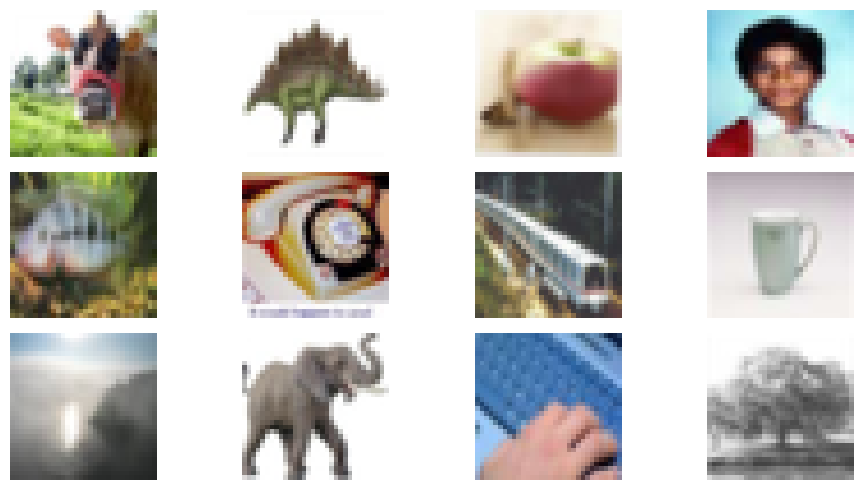

In [9]:
import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(3, 4, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(trnImage[i])
    ax.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")

plt.show()

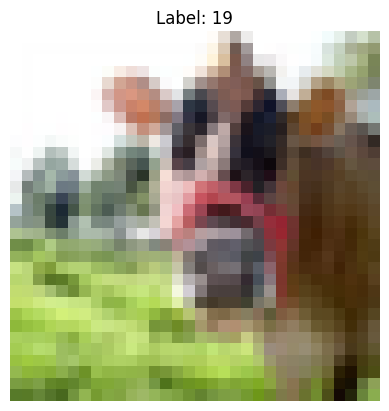

In [10]:
import matplotlib.pyplot as plt

img = trnImage[0]

plt.imshow(img)
plt.title(f"Label: {trnLabel_fine[0]}")
plt.axis('off')
plt.show()

#Method 1 — HOG + SVM

---
# HOG Feature Extraction

Histogram of Oriented Gradients (HOG) was used to extract hand-crafted image features.

HOG captures edge and gradient information from localized image regions and converts each image into a feature vector suitable for machine learning classifiers.


In [11]:
from skimage.feature import hog
from skimage.color import rgb2gray

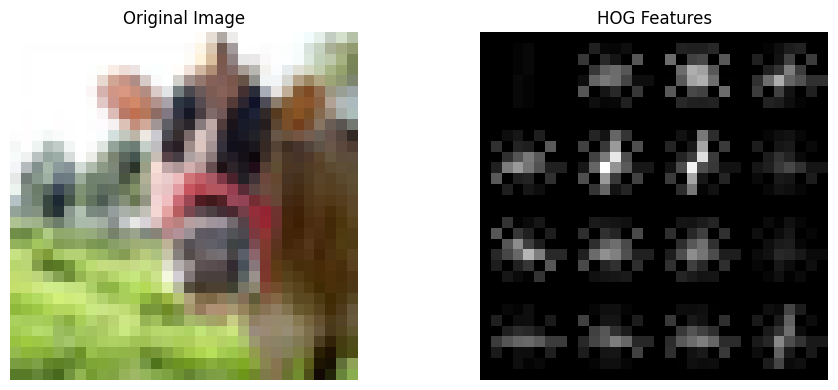

In [12]:
from skimage.feature import hog
from skimage import color
import matplotlib.pyplot as plt

# Example image
image = trnImage[0]

#Convert image to grayscale
gray = color.rgb2gray(image)

#Extract HOG features
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True
)

# Visualize original image and HOG features
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(hog_image, cmap='gray')
ax[1].set_title("HOG Features")
ax[1].axis('off')

plt.tight_layout()
plt.savefig("hog_visualization.png")
plt.show()

What we see on the right is:
Edges
Directions
Shape details
Meaning the model no longer sees a “cow image” like a human, it now sees digital patterns that help it distinguish categories.

In [ ]:
from skimage.feature import hog
from skimage.color import rgb2gray
# EXTRACT HOG FEATURES FOR ALL IMAGES
def extract_hog_features(images):

    hog_features = []

    for img in images:

        gray_img = rgb2gray(img)

        features = hog(
            gray_img,
            orientations=9,
            pixels_per_cell=(4,4),
            cells_per_block=(3,3),
            visualize=False
        )

        hog_features.append(features)

    return np.array(hog_features)

In [ ]:
# Extract features from training and testing images
X_train_hog = extract_hog_features(trnImage)
X_test_hog = extract_hog_features(tstImage)

In [ ]:
print(X_train_hog.shape)
print(X_test_hog.shape)

(50000, 2916)
(10000, 2916)




> # SVM Classification



A Linear Support Vector Machine (LinearSVC) classifier was trained using the extracted HOG feature vectors.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# Create model
svm_model = LinearSVC()

In [ ]:
svm_model.fit(X_train_hog, trnLabel_fine)#Model training

LinearSVC()

In [ ]:
y_pred = svm_model.predict(X_test_hog) #Prediction

In [ ]:
accuracy = accuracy_score(tstLabel_fine, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.1958





> Evaluation



The model performance was evaluated using:

- Classification accuracy
- Confusion matrix
- Prediction examples

In [ ]:
print(classification_report(tstLabel_fine, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.51      0.44       100
           1       0.12      0.16      0.14       100
           2       0.08      0.04      0.05       100
           3       0.11      0.06      0.08       100
           4       0.05      0.03      0.04       100
           5       0.20      0.26      0.22       100
           6       0.09      0.09      0.09       100
           7       0.12      0.09      0.10       100
           8       0.33      0.47      0.39       100
           9       0.39      0.54      0.45       100
          10       0.23      0.26      0.25       100
          11       0.17      0.11      0.13       100
          12       0.19      0.22      0.21       100
          13       0.13      0.13      0.13       100
          14       0.16      0.16      0.16       100
          15       0.17      0.15      0.16       100
          16       0.29      0.32      0.31       100
          17       0.16    

In [ ]:
cm = confusion_matrix(tstLabel_fine, y_pred)

print(cm.shape)

(100, 100)


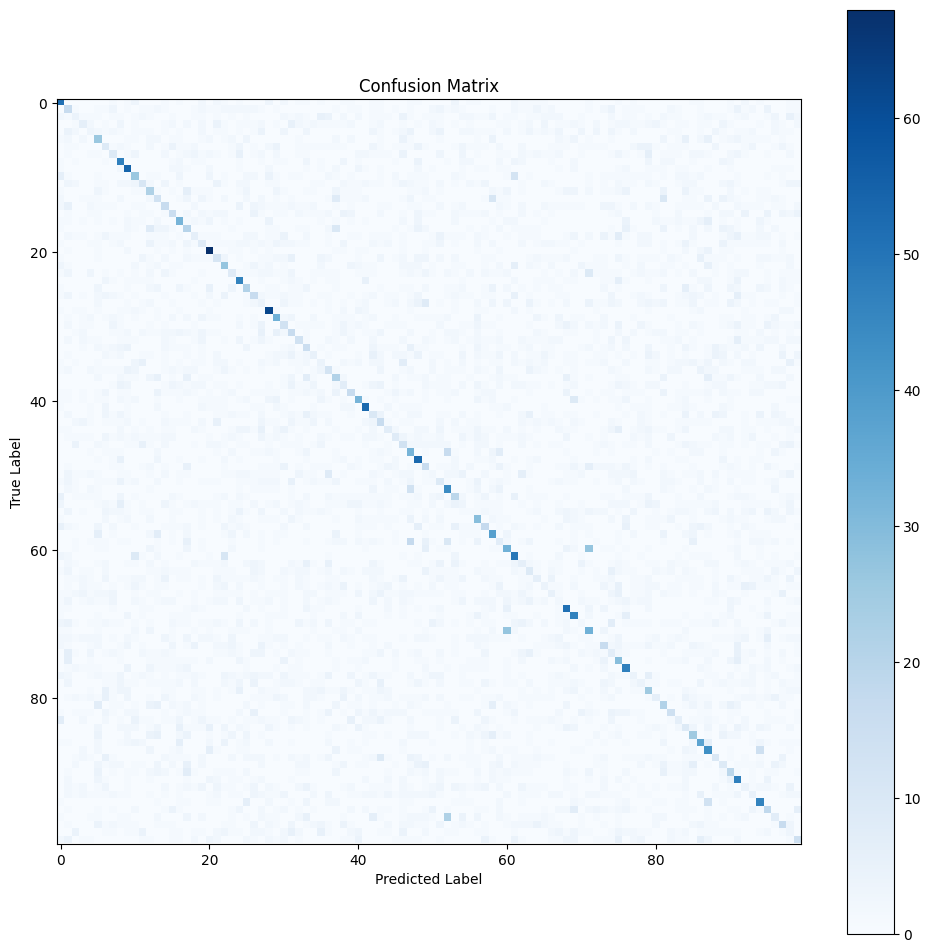

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.show()

In [ ]:
# PREDICTION EXAMPLE
sample_index = 0

sample_image = tstImage[sample_index]

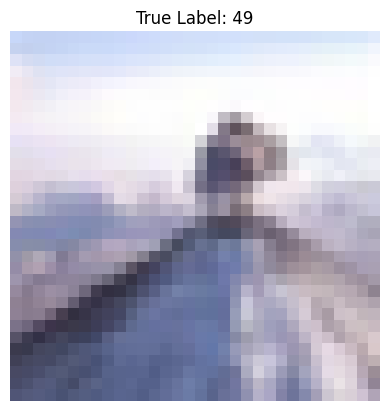

In [ ]:
plt.imshow(sample_image)
plt.title(f"True Label: {tstLabel_fine[sample_index]}")
plt.axis('off')
plt.show()

In [ ]:
gray_img = rgb2gray(sample_image)

sample_hog = hog(
    gray_img,
    pixels_per_cell=(4,4),
    cells_per_block=(3,3),
    visualize=False
)

sample_hog = sample_hog.reshape(1, -1)
prediction = svm_model.predict(sample_hog)

print("Predicted Label:", prediction[0])
print("True Label:", tstLabel_fine[sample_index])

Predicted Label: 79
True Label: 49


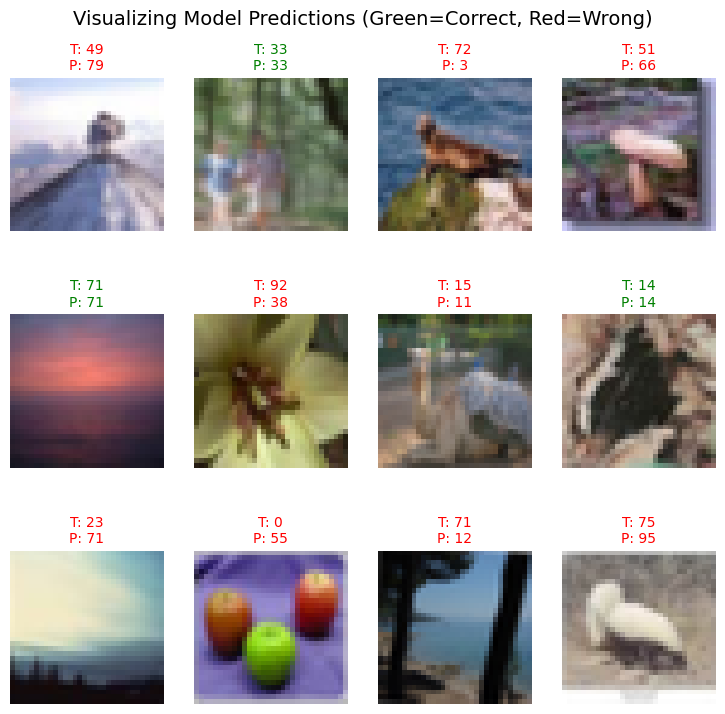

In [ ]:
def plot_gallery(images, true_labels, pred_labels, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i])

        color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        plt.title(f"T: {true_labels[i]}\nP: {pred_labels[i]}", color=color, fontsize=10)
        plt.axis('off')
    plt.suptitle("Visualizing Model Predictions (Green=Correct, Red=Wrong)", fontsize=14)
    plt.show()

plot_gallery(tstImage, tstLabel_fine, y_pred)

# Discussion

The HOG + SVM model achieved moderate classification performance.

Some image categories were difficult to classify correctly due to:
- low image resolution
- visual similarity between classes
- and limitations of hand-crafted features.


# Method 2 — CNN

---

# Convolutional Neural Network (CNN)
CNNs are widely used for image classification tasks it's automatically learn hierarchical image features directly from raw pixel data.



>  CNN Architecture


The CNN model consists of:
1) Convolutional layer with 64 filters and ReLU activation.
2) Max-pooling layer.
3) Second convolutional layer with 128 filters.
4) Additional max-pooling layer.
5) Flatten layer.
6) Fully connected dense layer.
7) Softmax output layer for classification



• Applying one-hot encoding for CNN classification labels.

In [13]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(trnLabel_fine, 100)
y_test = to_categorical(tstLabel_fine, 100)
print(y_train.shape)
print(y_test.shape)

(50000, 100)
(10000, 100)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [15]:
cnn_model = Sequential()

# Convolution Layer
cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

# Pooling Layer
cnn_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Conv Layer
cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

# Second Pooling
cnn_model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten
cnn_model.add(Flatten())

# Fully Connected
cnn_model.add(Dense(265, activation='relu'))

# Dropout
cnn_model.add(Dropout(0.5))

# Output Layer
cnn_model.add(Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
#An algorithm used to update the net weights during training.
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 265)            │     1,221,385 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 265)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        26,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,633 (5.05 MB)

 Trainable params: 1,323,633 (5.05 MB)

 Non-trainable params: 0 (0.00 B)



> Model Training



The CNN model was trained using the Adam optimizer and categorical cross-entropy loss function.

In [18]:
history = cnn_model.fit(
    trnImage,
    y_train,
    epochs=25,
    batch_size=64,
    validation_data=(tstImage, y_test) # train
 )

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 177s 223ms/step - accuracy: 0.0992 - loss: 3.9513 - val_accuracy: 0.2158 - val_loss: 3.3015
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 170s 218ms/step - accuracy: 0.1974 - loss: 3.3301 - val_accuracy: 0.2837 - val_loss: 2.9671
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 205s 222ms/step - accuracy: 0.2463 - loss: 3.0625 - val_accuracy: 0.3161 - val_loss: 2.7925
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 218ms/step - accuracy: 0.2794 - loss: 2.8924 - val_accuracy: 0.3481 - val_loss: 2.6153
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 172s 220ms/step - accuracy: 0.3020 - loss: 2.7738 - val_accuracy: 0.3550 - val_loss: 2.5932
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 170s 218ms/step - accuracy: 0.3236 - loss: 2.6627 - val_accuracy: 0.3646 - val_loss: 2.5210
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 205s 221ms/step - accuracy: 0.3432 - loss: 2.5707 - val_accuracy: 0.3815 - val_loss: 2.4631
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 173s 221ms/step - accuracy: 0.3564 -



> CNN Evaluation



The CNN model was evaluated on the testing dataset using classification accuracy and confusion_matrix.

In [19]:
test_loss, test_accuracy = cnn_model.evaluate(tstImage, y_test)

print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.3993 - loss: 2.5600
Test Accuracy: 0.3993000090122223


In [22]:
from sklearn.metrics import classification_report
import numpy as np

predictions = cnn_model.predict(tstImage)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step
              precision    recall  f1-score   support

           0       0.67      0.68      0.67       100
           1       0.47      0.53      0.50       100
           2       0.22      0.28      0.25       100
           3       0.21      0.23      0.22       100
           4       0.24      0.29      0.26       100
           5       0.30      0.34      0.32       100
           6       0.49      0.33      0.39       100
           7       0.45      0.42      0.44       100
           8       0.53      0.45      0.49       100
           9       0.49      0.55      0.52       100
          10       0.28      0.33      0.30       100
          11       0.36      0.17      0.23       100
          12       0.38      0.41      0.39       100
          13       0.32      0.28      0.30       100
          14       0.45      0.34      0.39       100
          15       0.35      0.30      0.32       100
          16       0.43      0.36     

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


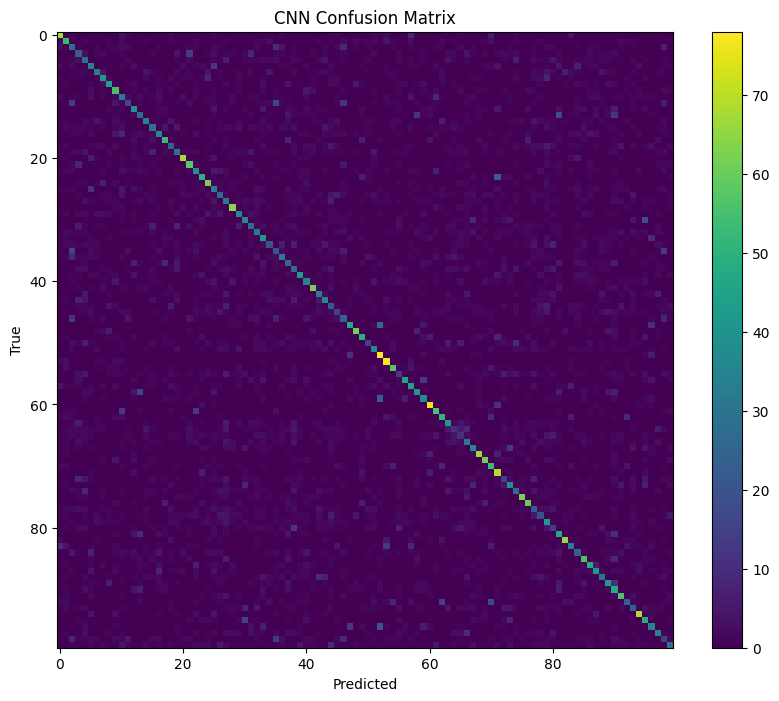

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

predictions = cnn_model.predict(tstImage)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.colorbar()

plt.savefig("confusion_matrix.png")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


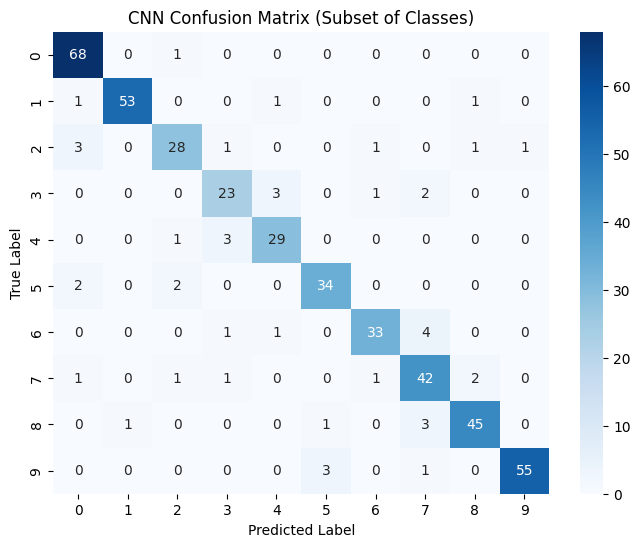

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# predictions
predictions = cnn_model.predict(tstImage)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

# first 10 classes
classes_to_show = list(range(10))


mask = np.isin(y_true, classes_to_show)

cm = confusion_matrix(
    y_true[mask],
    y_pred[mask],
    labels=classes_to_show
)

# رسم
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Confusion Matrix (Subset of Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("confusion_matrix.png")

plt.show()

# Comparison Between Methods

The CNN model achieved better performance than the HOG + SVM approach.

Reasons include:
- automatic feature learning
- better spatial representation
- and improved ability to capture complex visual patterns.

The HOG + SVM method was computationally simpler but less accurate for complex image classification tasks.

# Conclusion

This project investigated object recognition using two different classification approaches on the CIFAR-100 dataset: a traditional HOG-SVM pipeline and a Convolutional Neural Network model.

The HOG-SVM approach achieved a testing accuracy of 19.58\%, providing a functional baseline for image classification using handcrafted feature extraction. However, its performance remained limited when handling complex visual patterns and fine-grained object categories.

The CNN model achieved a significantly higher testing accuracy of 39.73\%, demonstrating the effectiveness of deep learning methods for automatic feature learning and object classification tasks.

Overall, the results demonstrate that convolutional neural networks provide superior performance for complex image recognition problems and are more suitable for large-scale computer vision applications involving substantial visual variation between object categories.